In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
#AT=TEMPARATURE
#V=VACCUM
#AP=PRESSURE
#RH=HUMIDITY
#PE=PRODUCED ENERGY

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
# PE = Target (Output)
# Remaining columns = Inputs (Features)
X=df.drop("PE",axis=1)
y=df["PE"]
y

0       480.48
1       445.75
2       438.76
3       453.09
4       464.43
         ...  
9563    462.59
9564    432.90
9565    465.96
9566    450.93
9567    451.67
Name: PE, Length: 9568, dtype: float64

In [7]:
#SPLIT OUT DATA
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# DATA TO TENSOR

In [1]:
# | Part    | Meaning               |
# | ------- | --------------------- |
# | `torch` | Main PyTorch library  |
# | `nn`    | Neural Network module |
# | `as nn` | Short name (alias)    |

#  Why do we use torch.nn?
# Because it provides ready made neural network components:
#  Layers
#  Loss functions
# Activation functions
#  Models
#Without this module, building ANN would be very difficult.

In [2]:
# 🔹 .values
# Converts pandas column → NumPy array.

# 🔹 .view(-1,1)
# Changes shape
# BEFORE
# [10,20,30,40]
# shape = (4,)
# AFTER
# [[10],
#  [20],
#  [30],
#  [40]]
# shape = (4,1)
# .view() changes the SHAPE of a tensor without changing data.
# Data same
# Arrangement changes

In [11]:
import torch
import torch.nn as nn
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

# TensorDataset and DataLoader

In [12]:
from torch.utils.data import TensorDataset,DataLoader
#Dataset
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [13]:
#DataLoader
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

# Deep Learning (Building ANN Model)

In [14]:
#Basics
#  What is __init__ ?
# Definition
# __init__ is a special function in Python that runs automatically when an object of a class is created.
# It is called a constructor.

# class Student:
#     def __init__(self, name):
#         self.name = name
#         #Create object:
#         s1 = Student("Raj")
#         #Python internally does:
#         Student.__init__(s1,"Raj")

#What is self ?
#self = current object
# It represents the object being created.

# Think Like This

# If:
# s1 = Student("Raj")
# then:
# self = s1

# If:
# s2 = Student("Amit")
# then:
# self = s2

# Define our ANN model

In [15]:
# nn.Module = Car Engine
# ANN = Car Body
# super() = Installing Engine

class ANN(nn.Module):#ANN inherits from nn.Module(so nn parent and ANN is child)
    def __init__(self):
        super(ANN,self).__init__()#It initializes parent class (nn.Module).
        
        #What is Sequential?:-It connects layers one after another automatically.
        self.model=nn.Sequential(
            #1st Hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2ND Hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            #Output layer
            nn.Linear(6,1),
        )
    #Forward passs(Data movement through network.)
    def forward(self,x):
        return self.model(x)

In [16]:
#Model Object Creation and loss function and optimizer
# ANN object created
#         ↓
# __init__ runs
#         ↓
# Layers initialized
#         ↓
# Model ready
import torch.optim as optim
model=ANN()

#Loss,Optimizer
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

# Training Our Model(ANN)

In [17]:
# For each epoch:
#     Set running_loss = 0

#     For each batch:
#         Forward
#         Compute loss
#         Backward
#         Update weights
#         Add loss to running_loss

#     After all batches:
#         Divide running_loss by total batches
#         Store average as epoch_train_loss

In [18]:
# running_loss = collects batch losses
# epoch_train_loss =gives average loss of whole dataset for that epoch
train_losses=[]
val_losses=[]

best_val_loss = float("inf")#Intially (infinity)

epochs=100
for epoch in range(epochs):
    model.train()
    running_loss=0.0#total training loss for 1 epoch

    for xb,yb in train_loader:
        #xb=features of 1 batch
        #yb=labels(output feature) of 1 batch
        optimizer.zero_grad()#clears (resets) all previously stored gradients before computing new ones in the next backward pass.

        outputs=model(xb)#forward prop......predicted outputs for this batch
        loss=criterion(outputs,yb)#Compute loss(predicted,actual)
        loss.backward()#back prop....compute gradients
        optimizer.step()#paramters update

        running_loss+=loss.item()#loss is a tensor ->py float
        
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    #Validation(During this no backward propgation because we are validating(testing )our model so model is aready trained)
    model.eval()
    running_val_loss=0.0

    with torch.no_grad():#No gradients computed 
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=criterion(outputs,yb)
            running_val_loss+=loss

    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)
  
    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")#.pt or .pth

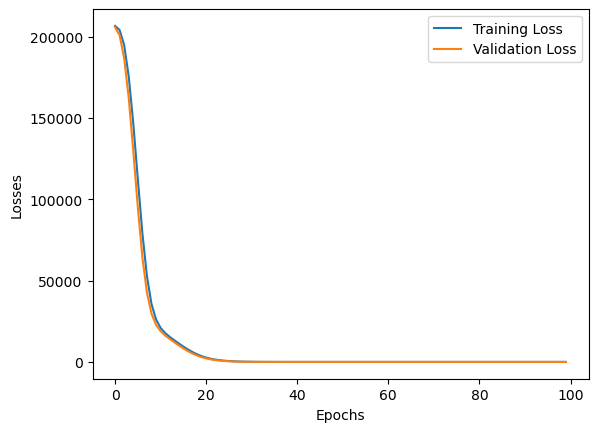

In [19]:
#Visualize the loss
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss":val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

# Loading the best model


In [20]:
# What is happening internally?

# torch.load("best_model.pt")
# → Loads the saved parameter dictionary (weights & biases).

# model.load_state_dict(...)
# → Puts those saved weights into your model.
#“Load the best learned brain into my model.”

In [21]:
model.load_state_dict(torch.load("best_model.pt"))

C:\Users\Vedant\AppData\Local\Temp\ipykernel_8684\349716640.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

# Evaluation

In [23]:
model.eval()
with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)

    train_mse_loss=criterion(train_preds,y_train_tensor)
    test_mse_loss=criterion(test_preds,y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.67180061340332
Testing MSE: 19.034019470214844


In [27]:
from sklearn.metrics import r2_score
print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9334810172481811


In [28]:
#Predicted vs actual value
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.509277,433.27
1,436.978333,438.16
2,461.587067,458.42
3,476.497986,480.82
4,435.551422,441.41
...,...,...
1909,451.524994,456.70
1910,431.767090,438.04
1911,467.888123,467.80
1912,431.166840,437.14
